# Running an aquaplanet test case

First we set up the mpi environment:

In [1]:
from pyrte_rrtmgp.rrtmgp_data_files import download_rrtmgp_data

download_rrtmgp_data()

'/root/.cache/pyrte_rrtmgp/rrtmgp-data-1.9'

In [2]:
import ipyparallel as ipp
ntiles = 6
layout = (1, 1)

num_ranks = ntiles * layout[0] * layout[1]
cluster = ipp.Cluster(engines="mpi", n=num_ranks).start_and_connect_sync()

# start executing cells on the workers in parallel from here on
%autopx

Starting 6 engines with <class 'ipyparallel.cluster.launcher.MPIEngineSetLauncher'>
100%|████████████████████████████████████████████████████████████████████████████| 6/6 [00:05<00:00,  1.08engine/s]
%autopx enabled


In [3]:
from mpi4py import MPI

mpi_comm = MPI.COMM_WORLD
mpi_size = mpi_comm.Get_size()
mpi_rank = mpi_comm.Get_rank()

print(f"I am MPI-rank {mpi_rank} of a total of {mpi_size}")

[stdout:0] I am MPI-rank 0 of a total of 6


[stdout:1] I am MPI-rank 1 of a total of 6


[stdout:3] I am MPI-rank 3 of a total of 6


[stdout:4] I am MPI-rank 4 of a total of 6


[stdout:2] I am MPI-rank 2 of a total of 6


[stdout:5] I am MPI-rank 5 of a total of 6


In [4]:
%%time

from pace import Driver, DriverConfig
import yaml
import os

os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

config_file = "aquaplanet_c16.yaml"

j=0

with open(config_file, "r") as f:
    driver_config = DriverConfig.from_dict(yaml.safe_load(f))
driver = Driver(config=driver_config)

[output:1]

[output:4]

[output:2]

[output:5]

[output:0]

...

[stderr:3] /usr/local/lib/python3.12/site-packages/pyfv3/initialization/test_cases/initialize_aquaplanet.py:24: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  field_shape = (*sample_quantity.field.shape[0:2], grid_data.ak.data.shape[0])
/usr/local/lib/python3.12/site-packages/pyfv3/initialization/test_cases/initialize_aquaplanet.py:25: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  data_shape = (*sample_quantity.data.shape[0:2], grid_data.ak.data.shape[0])
/usr/local/lib/python3.12/site-packages/pyfv3/initialization/test_cases/initialize_aquaplanet.py:70: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  ak=utils.asarray(grid_data.ak.data),
/usr/local/l

[stderr:1] /usr/local/lib/python3.12/site-packages/pyfv3/initialization/test_cases/initialize_aquaplanet.py:24: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  field_shape = (*sample_quantity.field.shape[0:2], grid_data.ak.data.shape[0])
/usr/local/lib/python3.12/site-packages/pyfv3/initialization/test_cases/initialize_aquaplanet.py:25: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  data_shape = (*sample_quantity.data.shape[0:2], grid_data.ak.data.shape[0])
/usr/local/lib/python3.12/site-packages/pyfv3/initialization/test_cases/initialize_aquaplanet.py:70: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  ak=utils.asarray(grid_data.ak.data),
/usr/local/l

[stderr:0] /usr/local/lib/python3.12/site-packages/pyfv3/initialization/test_cases/initialize_aquaplanet.py:24: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  field_shape = (*sample_quantity.field.shape[0:2], grid_data.ak.data.shape[0])
/usr/local/lib/python3.12/site-packages/pyfv3/initialization/test_cases/initialize_aquaplanet.py:25: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  data_shape = (*sample_quantity.data.shape[0:2], grid_data.ak.data.shape[0])
/usr/local/lib/python3.12/site-packages/pyfv3/initialization/test_cases/initialize_aquaplanet.py:70: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  ak=utils.asarray(grid_data.ak.data),
/usr/local/l

[stderr:4] /usr/local/lib/python3.12/site-packages/pyfv3/initialization/test_cases/initialize_aquaplanet.py:24: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  field_shape = (*sample_quantity.field.shape[0:2], grid_data.ak.data.shape[0])
/usr/local/lib/python3.12/site-packages/pyfv3/initialization/test_cases/initialize_aquaplanet.py:25: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  data_shape = (*sample_quantity.data.shape[0:2], grid_data.ak.data.shape[0])
/usr/local/lib/python3.12/site-packages/pyfv3/initialization/test_cases/initialize_aquaplanet.py:70: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  ak=utils.asarray(grid_data.ak.data),
/usr/local/l

%px: 100%|████████████████████████████████████████████████████████████████████████| 6/6 [01:47<00:00, 17.98s/tasks]


In [5]:
print(f"Rank {mpi_rank}", driver.state.grid_data.lon_agrid.shape)
if mpi_rank == 0:
    print(driver_config.physics_config.nsswr)
    print(driver_config.physics_config.dt_atmos)
    print(driver.physics._gridlat.field[:].max(), driver.physics._gridlat.field[:].min())

[stdout:1] Rank 1 (27, 27)


[stdout:5] Rank 5 (27, 27)


[stdout:0] Rank 0 (27, 27)
8
450
0.7515676556079762 -0.7515676556079762


[stdout:2] Rank 2 (27, 27)


[stdout:3] Rank 3 (27, 27)


[stdout:4] Rank 4 (27, 27)


We can inspect the initial model state:

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from cartopy import crs as ccrs
from fv3viz import pcolormesh_cube
from ndsl import CubedSphereCommunicator

communicator = CubedSphereCommunicator.from_layout(
    comm=driver.comm,
    layout=driver.config.layout,
)
grid_lon = communicator.gather(driver.state.grid_data.lon)
grid_lat = communicator.gather(driver.state.grid_data.lat)
a_lon = communicator.gather(driver.state.grid_data.lon_agrid)
a_lat = communicator.gather(driver.state.grid_data.lat_agrid)
temperature = communicator.gather(driver.state.dycore_state.pt)
surface_pressure = communicator.gather(driver.state.dycore_state.ps)
edge_pressure = communicator.gather(driver.state.dycore_state.pe)
u_wind = communicator.gather(driver.state.dycore_state.u)
v_wind = communicator.gather(driver.state.dycore_state.v)
qrain = communicator.gather(driver.state.dycore_state.qrain)
qvap = communicator.gather(driver.state.dycore_state.qvapor)
qcld = communicator.gather(driver.state.dycore_state.qcld)
qo3mr = communicator.gather(driver.state.dycore_state.qo3mr)
phil = communicator.gather(driver.state.physics_state.phil)
land = communicator.gather(driver.state.physics_state.land)
fswd = communicator.gather(driver.state.radiation_state.fswd)
flwu = communicator.gather(driver.state.radiation_state.flwu)
flwd = communicator.gather(driver.state.radiation_state.flwd)
fswn = communicator.gather(driver.state.radiation_state.fswn)
prsl = communicator.gather(driver.state.radiation_state.prsl)
sst = communicator.gather(driver.state.sfc_state.tsfc)
ffmm = communicator.gather(driver.state.sfc_state.ffmm)
ffhh = communicator.gather(driver.state.sfc_state.ffhh)
sfcemis = communicator.gather(driver.state.sfc_state.sfcemis)
islmsk = communicator.gather(driver.state.sfc_state.islmsk)

[stdout:0] (6, 20, 20, 79)
(6, 21, 21)
(6, 21, 21)
(27, 27, 80)
299.50309077839216 299.50309077839216
100000.00000000003 100000.00000000003
299.50309077839216 299.50309077839216
100000.00000000003 100000.00000000003
299.50309077839216 299.50309077839216
100000.00000000003 100000.00000000003
299.50309077839216 299.50309077839216
100000.00000000003 100000.00000000003
299.50309077839216 299.50309077839216
100000.00000000003 100000.00000000003
299.50309077839216 299.50309077839216
100000.00000000003 100000.00000000003
100000.00000000003 300.0
0.0 0.0
0.0 0.0
[86120.566 86120.566 86120.566 86120.566 86120.566 86120.566]
200.0 299.8477738738773


[stderr:0] /tmp/ipykernel_387/3187894426.py:3: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  print(grid_lon.data.shape)
/tmp/ipykernel_387/3187894426.py:11: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  print(edge_pressure.data[:].max(), edge_pressure.data[:].min())
/tmp/ipykernel_387/3187894426.py:12: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  print(fswd.data[:].max(), fswd.data[:].min())
/tmp/ipykernel_387/3187894426.py:13: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  print(flwu.data[:].max(), flwu.data[:].min())
/tmp/ipykernel_

[output:0]

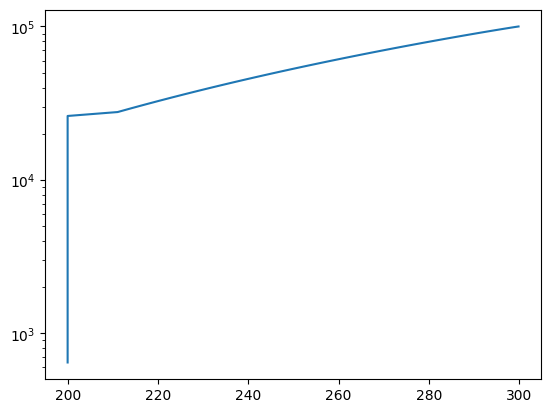

In [7]:
if mpi_rank == 0:
    print(temperature.shape)
    print(grid_lon.data.shape)
    print(grid_lat.shape)
    print(driver.state.dycore_state.pt.shape)
#     print(driver.state.dycore_state.pt.field[:,:,-2])
    for r in range(6):
        print(temperature.field[r, :, :, -2].min(), temperature.field[r, :, :, -2].max())
        print(surface_pressure.field[r, :, :].min(), surface_pressure.field[r, :, :].max())
    plt.semilogy(driver.state.dycore_state.pt.field[6, 6, :], driver.state.dycore_state.pe.field[6, 6, 1:])
    print(edge_pressure.data[:].max(), edge_pressure.data[:].min())
    print(fswd.data[:].max(), fswd.data[:].min())
    print(flwu.data[:].max(), flwu.data[:].min())
    print(edge_pressure.data[:,5,5,-16])
    print(driver.state.dycore_state.pt.field.min(), driver.state.dycore_state.pt.field.max())

[output:4]

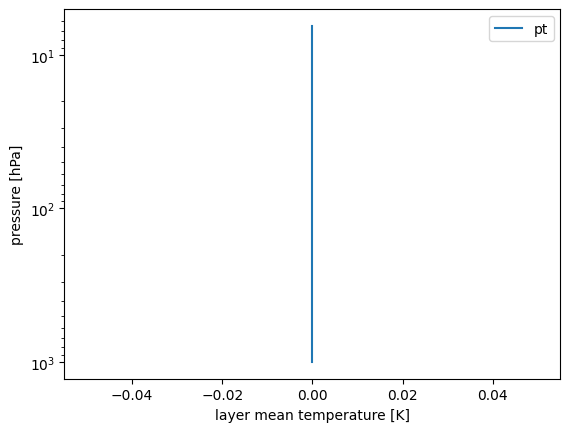

In [8]:
if mpi_rank == 4:
    px=6
    py=8
    plt.gca().invert_yaxis()
    plt.semilogy(driver.state.physics_state.pt.field[px, py, :], driver.state.dycore_state.pe.field[px, py, 1:]/100, label="pt")
    plt.xlabel("layer mean temperature [K]")
    plt.ylabel("pressure [hPa]")
    plt.legend()

[stdout:0] 299.50309077839216


[stderr:0] /tmp/ipykernel_387/254248933.py:13: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  grid_lat.data * 180./np.pi,
/tmp/ipykernel_387/254248933.py:14: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  grid_lon.data * 180./np.pi,
/tmp/ipykernel_387/254248933.py:24: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  grid_lat.data * 180./np.pi,
/tmp/ipykernel_387/254248933.py:25: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  grid_lon.data * 180./np.pi,
/tmp/ipykernel_387/254248933.py:26: UserWarning: Quantity.data accessor is now deprecated

[output:0]

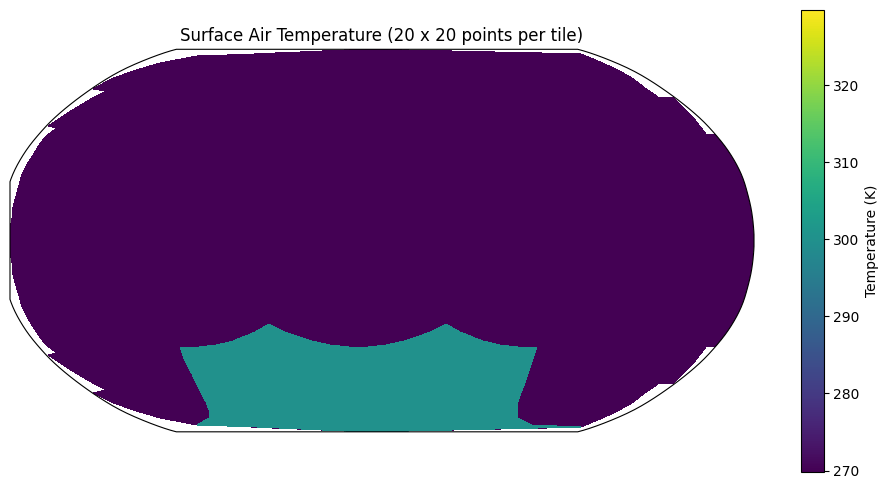

[output:0]

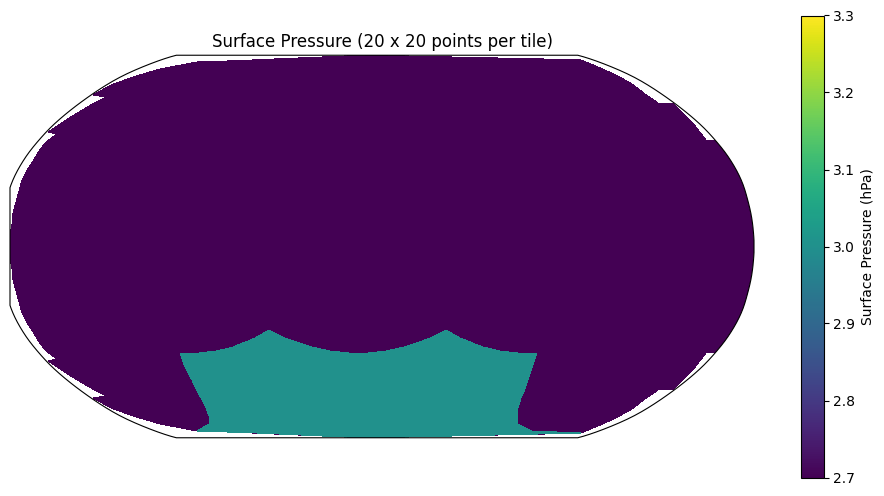

[output:0]

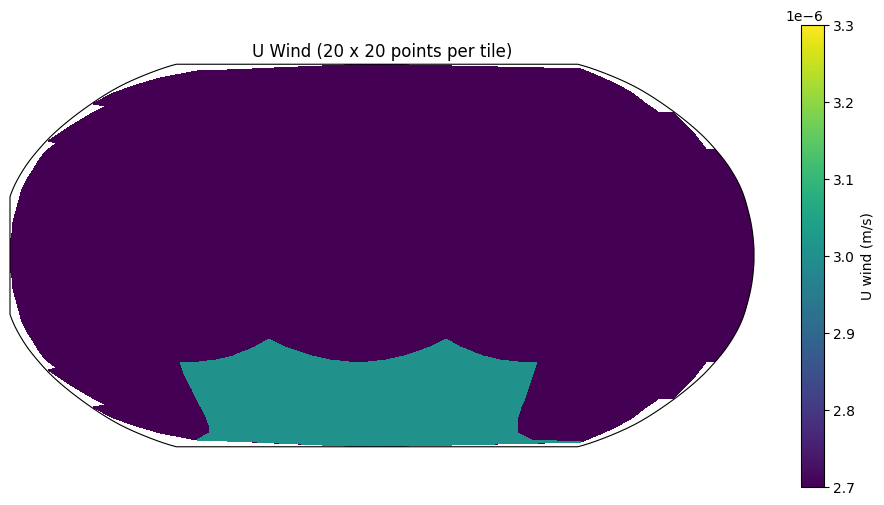

[output:0]

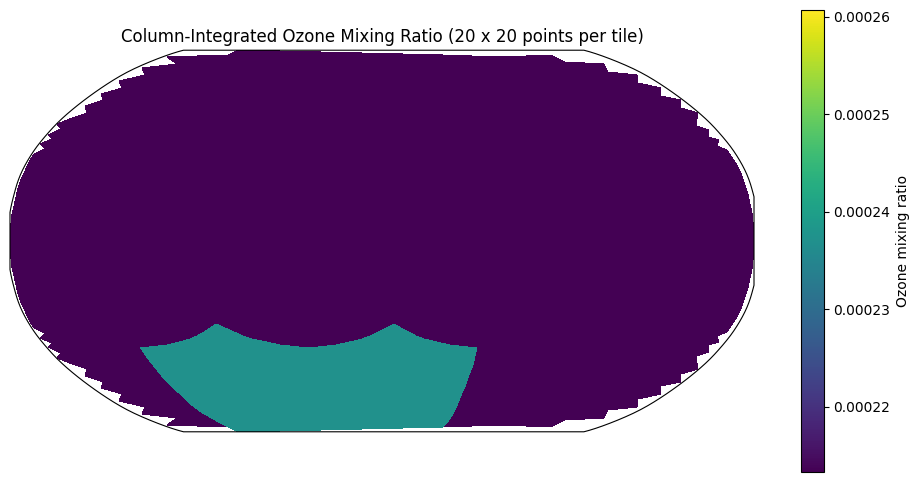

In [9]:
if mpi_rank == 0:
    rotation = -120.
    nx = temperature.shape[1]
    nz = temperature.shape[3]
    u_mean = 0.5 * (u_wind.field[:,:,:-1, :] + u_wind.field[:,:, 1:, :])
    print(temperature.field[:, :, :, -2].min())
    column_qo3 = np.sum(qo3mr, axis=3)
    
    nx = temperature.shape[1]
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi,
        temperature.field[:, :, :, -1],
        cmap="viridis",
    )
    plt.colorbar(f1, label="Temperature (K)")
    ax.set_title(f"Surface Air Temperature ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi,
        edge_pressure.data[:, :, :, 0]/100.,
        cmap="viridis",
    )
    plt.colorbar(f1, label="Surface Pressure (hPa)")
    ax.set_title(f"Surface Pressure ({nx} x {nx} points per tile)")
    
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi,
        qcld.data[:,:,:,16],
        cmap="viridis",
    )
    plt.colorbar(f1, label="U wind (m/s)")
    ax.set_title(f"U Wind ({nx} x {nx} points per tile)")

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qo3,
        cmap="viridis",
    )
    plt.colorbar(f1, label="Ozone mixing ratio")
    ax.set_title(f"Column-Integrated Ozone Mixing Ratio ({nx} x {nx} points per tile)")

[stdout:0] False


[output:0]

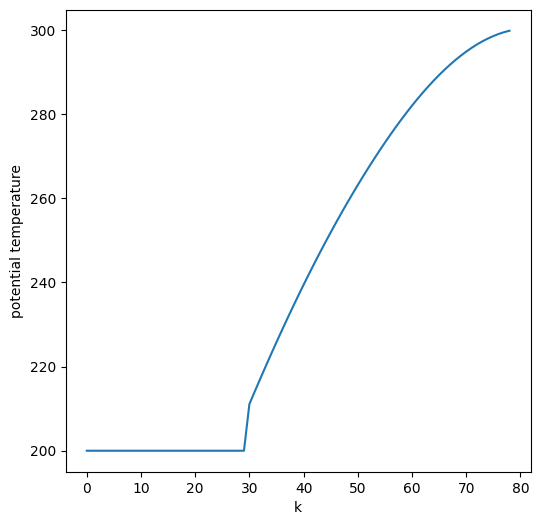

[output:0]

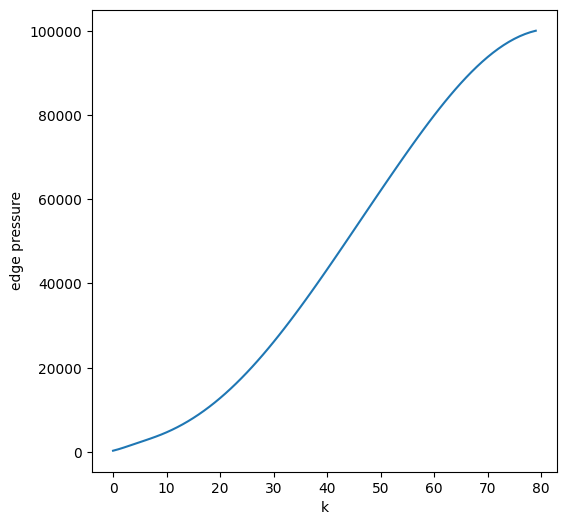

[output:0]

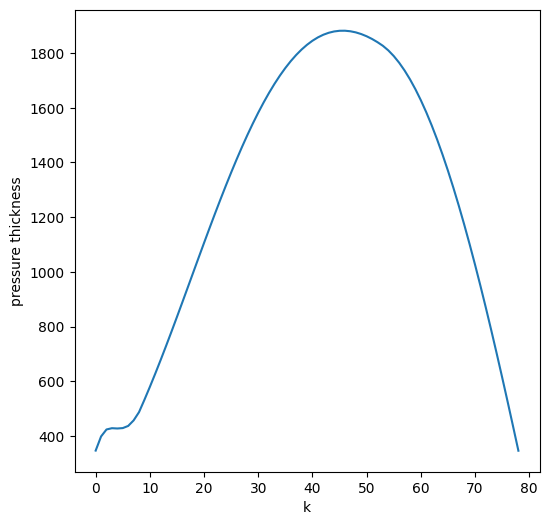

[output:0]

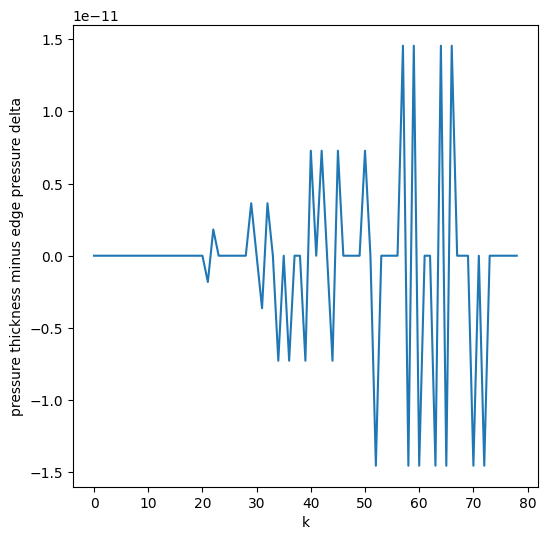

In [10]:
if mpi_rank == 0:
    pe = driver.state.dycore_state.pe.field[6, 6, :]
    delp = driver.state.dycore_state.delp.field[6, 6, :]
    print(np.all(pe[1:]==pe[:-1]+delp))
    
    fig1 = plt.figure(figsize=(6, 6))
    ax1 = fig1.add_subplot(111)
    f1 = ax1.plot(driver.state.dycore_state.pt.field[6, 6, :])
    ax1.set_xlabel("k")
    ax1.set_ylabel("potential temperature")
    
    fig2 = plt.figure(figsize=(6, 6))
    ax2 = fig2.add_subplot(111)
    f2 = ax2.plot(driver.state.dycore_state.pe.field[6, 6, :])
    ax2.set_xlabel("k")
    ax2.set_ylabel("edge pressure")
    
    fig3 = plt.figure(figsize=(6, 6))
    ax3 = fig3.add_subplot(111)
    f3 = ax3.plot(driver.state.dycore_state.delp.field[6, 6, :])
    ax3.set_xlabel("k")
    ax3.set_ylabel("pressure thickness")
    
    fig4 = plt.figure(figsize=(6, 6))
    ax4 = fig4.add_subplot(111)
    ax4.plot(delp + pe[:-1] - pe[1:])
    ax4.set_xlabel("k")
    ax4.set_ylabel("pressure thickness minus edge pressure delta")
    

In [11]:
if mpi_rank == 0:
    pe = driver.state.dycore_state.pe.field[6, 6, :]
    delp = driver.state.dycore_state.delp.field[6, 6, :]
    print(np.all(np.isclose(pe[:-1]+delp-pe[1:], 0)))
    print(driver.state.dycore_state.ps.field[6, 6])
    print(driver.state.dycore_state.phis.field[6, 6])

[stdout:0] True
100000.00000000003
0.0


[output:0]

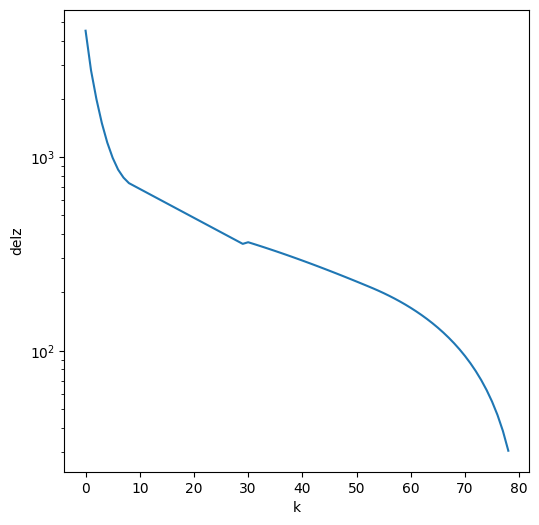

[output:0]

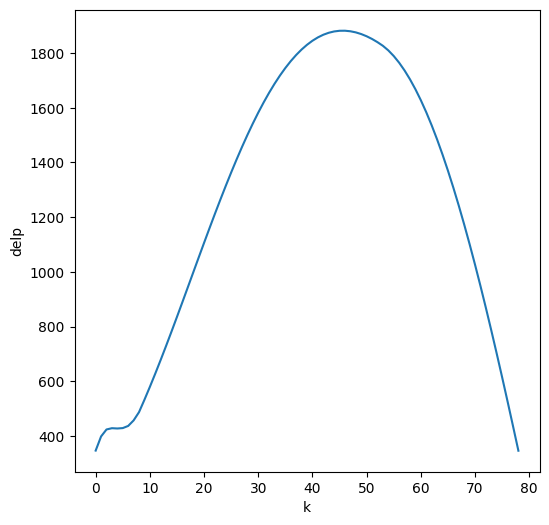

[output:0]

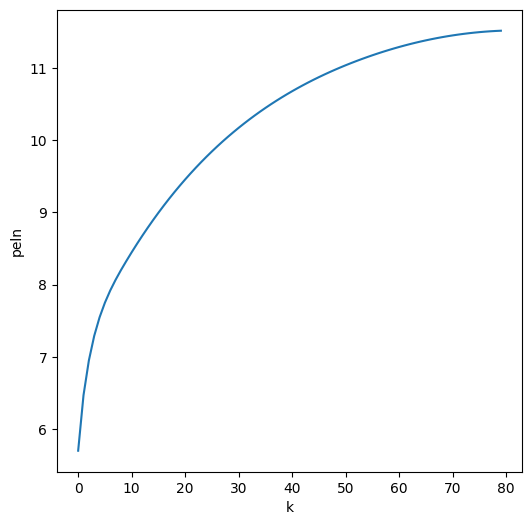

[output:0]

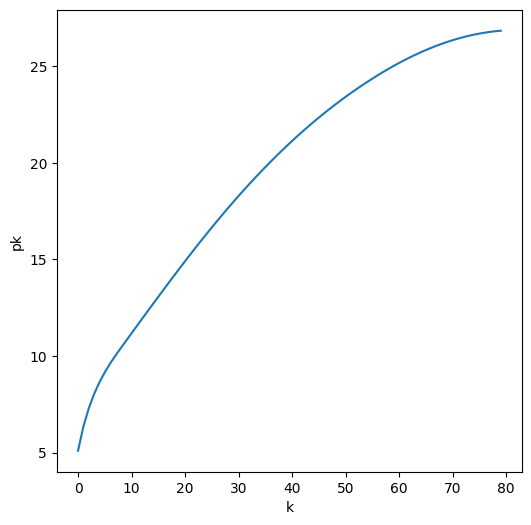

[output:0]

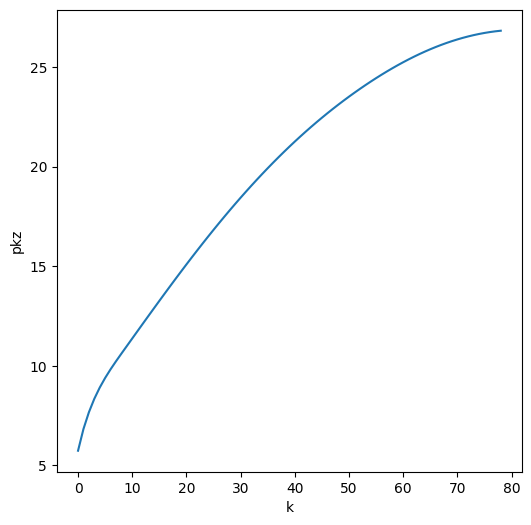

[output:0]

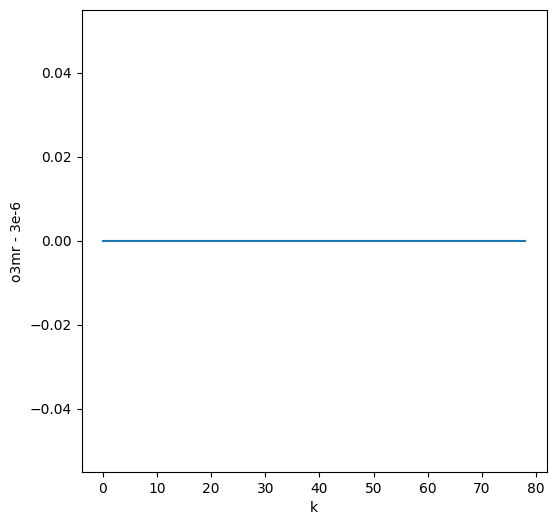

In [12]:
if mpi_rank == 0:
    state = driver.state.dycore_state
    
    fig1 = plt.figure(figsize=(6, 6))
    ax1 = fig1.add_subplot(111)
    f1 = ax1.semilogy(-state.delz.field[6, 6, :])
    ax1.set_xlabel("k")
    ax1.set_ylabel("delz")
    
    fig2 = plt.figure(figsize=(6, 6))
    ax2 = fig2.add_subplot(111)
    f2 = ax2.plot(driver.state.dycore_state.delp.field[6, 6, :])
    ax2.set_xlabel("k")
    ax2.set_ylabel("delp")
    
    fig3 = plt.figure(figsize=(6, 6))
    ax3 = fig3.add_subplot(111)
    f3 = ax3.plot(driver.state.dycore_state.peln.field[6, 6, :])
    ax3.set_xlabel("k")
    ax3.set_ylabel("peln")
    
    fig4 = plt.figure(figsize=(6, 6))
    ax4 = fig4.add_subplot(111)
    f4 = ax4.plot(driver.state.dycore_state.pk.field[6, 6, :])
    ax4.set_xlabel("k")
    ax4.set_ylabel("pk")
    
    fig5 = plt.figure(figsize=(6, 6))
    ax5 = fig5.add_subplot(111)
    f5 = ax5.plot(driver.state.dycore_state.pkz.field[6, 6, :])
    ax5.set_xlabel("k")
    ax5.set_ylabel("pkz")

    fig6 = plt.figure(figsize=(6, 6))
    ax6 = fig6.add_subplot(111)
    f6 = ax6.plot(driver.state.dycore_state.qo3mr.field[6, 6, :]-3.e-6)
    ax6.set_xlabel("k")
    ax6.set_ylabel("o3mr - 3e-6")
#     ax6.set_ylim(2.9e-6, 3.1e-6)

# And then we can run the model:

In [13]:
%%time
# import tracemalloc
# if mpi_rank == 0:
#     tracemalloc.start()
#     snapshot1 = tracemalloc.take_snapshot()
# driver.step_one(j)
# j += 1
# if mpi_rank == 0:
#     snapshot2 = tracemalloc.take_snapshot()
# for i in range(34):
#     driver.step_one(j)
#     j += 1
# if mpi_rank == 0:
#     snapshot3 = tracemalloc.take_snapshot()
#     top_stats1 = snapshot2.compare_to(snapshot1, 'lineno')
#     top_stats2 = snapshot3.compare_to(snapshot1, 'lineno')
try:
    driver.step_all()
finally:
    driver.cleanup()

[stdout:0] 2026-07-22 15:42:25|INFO|rank 0|ndsl.logging:integrating driver forward in time
2026-07-22 15:42:25|WARNING|rank 0|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 20 < 26.
2026-07-22 15:42:25|WARNING|rank 0|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 20 < 26.
2026-07-22 15:42:25|WARNING|rank 0|ndsl.logging:Found an array-type argument q_out that is not a Quantity. Some domain-size checks are omitted.
2026-07-22 15:42:26|INFO|rank 0|ndsl.logging:FV Setup
2026-07-22 15:42:26|WARNING|rank 0|ndsl.logging:Found an array-type argument qvapor that is not a Quantity. Some domain-size checks are omitted.
2026-07-22 15:42:26|WARNING|rank 0|ndsl.logging:Found an array-type argument qliquid that is not a Quantity. Some domain-size checks are omitted.
2026-07-22 15:42:26|WARNING|rank 0|ndsl.logging:Found an array-type argument qrain that is not a Quantity. Some domain-size checks are omitted.
2026-07-22 15:42:26|WARNING|rank 0

[stdout:4] 2026-07-22 15:42:25|INFO|rank 4|ndsl.logging:integrating driver forward in time
2026-07-22 15:42:25|WARNING|rank 4|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 20 < 26.
2026-07-22 15:42:25|WARNING|rank 4|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 20 < 26.
2026-07-22 15:42:25|WARNING|rank 4|ndsl.logging:Found an array-type argument q_out that is not a Quantity. Some domain-size checks are omitted.
2026-07-22 15:42:26|WARNING|rank 4|ndsl.logging:Found an array-type argument qvapor that is not a Quantity. Some domain-size checks are omitted.
2026-07-22 15:42:26|WARNING|rank 4|ndsl.logging:Found an array-type argument qliquid that is not a Quantity. Some domain-size checks are omitted.
2026-07-22 15:42:26|WARNING|rank 4|ndsl.logging:Found an array-type argument qrain that is not a Quantity. Some domain-size checks are omitted.
2026-07-22 15:42:26|WARNING|rank 4|ndsl.logging:Found an array-type argument qsnow that 

[stdout:5] 2026-07-22 15:42:25|INFO|rank 5|ndsl.logging:integrating driver forward in time
2026-07-22 15:42:25|WARNING|rank 5|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 20 < 26.
2026-07-22 15:42:25|WARNING|rank 5|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 20 < 26.
2026-07-22 15:42:25|WARNING|rank 5|ndsl.logging:Found an array-type argument q_out that is not a Quantity. Some domain-size checks are omitted.
2026-07-22 15:42:26|WARNING|rank 5|ndsl.logging:Found an array-type argument qvapor that is not a Quantity. Some domain-size checks are omitted.
2026-07-22 15:42:26|WARNING|rank 5|ndsl.logging:Found an array-type argument qliquid that is not a Quantity. Some domain-size checks are omitted.
2026-07-22 15:42:26|WARNING|rank 5|ndsl.logging:Found an array-type argument qrain that is not a Quantity. Some domain-size checks are omitted.
2026-07-22 15:42:26|WARNING|rank 5|ndsl.logging:Found an array-type argument qsnow that 

[stdout:2] 2026-07-22 15:42:25|INFO|rank 2|ndsl.logging:integrating driver forward in time
2026-07-22 15:42:25|WARNING|rank 2|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 20 < 26.
2026-07-22 15:42:25|WARNING|rank 2|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 20 < 26.
2026-07-22 15:42:25|WARNING|rank 2|ndsl.logging:Found an array-type argument q_out that is not a Quantity. Some domain-size checks are omitted.
2026-07-22 15:42:26|WARNING|rank 2|ndsl.logging:Found an array-type argument qvapor that is not a Quantity. Some domain-size checks are omitted.
2026-07-22 15:42:26|WARNING|rank 2|ndsl.logging:Found an array-type argument qliquid that is not a Quantity. Some domain-size checks are omitted.
2026-07-22 15:42:26|WARNING|rank 2|ndsl.logging:Found an array-type argument qrain that is not a Quantity. Some domain-size checks are omitted.
2026-07-22 15:42:26|WARNING|rank 2|ndsl.logging:Found an array-type argument qsnow that 

[stdout:1] 2026-07-22 15:42:25|INFO|rank 1|ndsl.logging:integrating driver forward in time
2026-07-22 15:42:25|WARNING|rank 1|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 20 < 26.
2026-07-22 15:42:25|WARNING|rank 1|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 20 < 26.
2026-07-22 15:42:25|WARNING|rank 1|ndsl.logging:Found an array-type argument q_out that is not a Quantity. Some domain-size checks are omitted.
2026-07-22 15:42:26|WARNING|rank 1|ndsl.logging:Found an array-type argument qvapor that is not a Quantity. Some domain-size checks are omitted.
2026-07-22 15:42:26|WARNING|rank 1|ndsl.logging:Found an array-type argument qliquid that is not a Quantity. Some domain-size checks are omitted.
2026-07-22 15:42:26|WARNING|rank 1|ndsl.logging:Found an array-type argument qrain that is not a Quantity. Some domain-size checks are omitted.
2026-07-22 15:42:26|WARNING|rank 1|ndsl.logging:Found an array-type argument qsnow that 

...

[stderr:3] /usr/local/lib/python3.12/site-packages/pyfv3/stencils/copy_corners.py:115: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  _blind_copy_corners_y(field_to_copy.data)
/pace/examples/notebooks/.gt_cache_000003/py312_1013/debug/pyfv3/stencils/yppm/compute_y_flux/m_computation__debug_87128056c6.py:32: RuntimeWarning: invalid value encountered in scalar divide
  al__3be_15_17_gen_0 = ( 0.5 * ( ( ( ( ( ( 2.0 * dya[i + 0,j + -1].item() ) + dya[i + 0,j + -2].item() ) * q[i + 0,j + -1,k + 0] ) - ( dya[i + 0,j + -1].item() * q[i + 0,j + -2,k + 0] ) ) / ( dya[i + 0,j + -2].item() + dya[i + 0,j + -1].item() ) ) + ( ( ( ( ( 2.0 * dya[i + 0,j + 0].item() ) + dya[i + 0,j + 1].item() ) * q[i + 0,j + 0,k + 0] ) - ( dya[i + 0,j + 0].item() * q[i + 0,j + 1,k + 0] ) ) / ( dya[i + 0,j + 0].item() + dya[i + 0,j + 1].item() ) ) ) )
/pace/examples/notebooks/.gt_cache_000003/py312_1013/de

[stderr:4] /usr/local/lib/python3.12/site-packages/pyfv3/stencils/copy_corners.py:115: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  _blind_copy_corners_y(field_to_copy.data)
/pace/examples/notebooks/.gt_cache_000004/py312_1013/debug/pyfv3/stencils/yppm/compute_y_flux/m_computation__debug_87128056c6.py:32: RuntimeWarning: invalid value encountered in scalar divide
  al__3be_15_17_gen_0 = ( 0.5 * ( ( ( ( ( ( 2.0 * dya[i + 0,j + -1].item() ) + dya[i + 0,j + -2].item() ) * q[i + 0,j + -1,k + 0] ) - ( dya[i + 0,j + -1].item() * q[i + 0,j + -2,k + 0] ) ) / ( dya[i + 0,j + -2].item() + dya[i + 0,j + -1].item() ) ) + ( ( ( ( ( 2.0 * dya[i + 0,j + 0].item() ) + dya[i + 0,j + 1].item() ) * q[i + 0,j + 0,k + 0] ) - ( dya[i + 0,j + 0].item() * q[i + 0,j + 1,k + 0] ) ) / ( dya[i + 0,j + 0].item() + dya[i + 0,j + 1].item() ) ) ) )
/pace/examples/notebooks/.gt_cache_000004/py312_1013/de

%px:   0%|                                                                                | 0/6 [00:14<?, ?tasks/s]

[stderr:0] /usr/local/lib/python3.12/site-packages/pyfv3/stencils/copy_corners.py:115: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  _blind_copy_corners_y(field_to_copy.data)
/pace/examples/notebooks/.gt_cache_000000/py312_1013/debug/pyfv3/stencils/yppm/compute_y_flux/m_computation__debug_87128056c6.py:32: RuntimeWarning: invalid value encountered in scalar divide
  al__3be_15_17_gen_0 = ( 0.5 * ( ( ( ( ( ( 2.0 * dya[i + 0,j + -1].item() ) + dya[i + 0,j + -2].item() ) * q[i + 0,j + -1,k + 0] ) - ( dya[i + 0,j + -1].item() * q[i + 0,j + -2,k + 0] ) ) / ( dya[i + 0,j + -2].item() + dya[i + 0,j + -1].item() ) ) + ( ( ( ( ( 2.0 * dya[i + 0,j + 0].item() ) + dya[i + 0,j + 1].item() ) * q[i + 0,j + 0,k + 0] ) - ( dya[i + 0,j + 0].item() * q[i + 0,j + 1,k + 0] ) ) / ( dya[i + 0,j + 0].item() + dya[i + 0,j + 1].item() ) ) ) )
/pace/examples/notebooks/.gt_cache_000000/py312_1013/de

%px: 100%|█████████████████████████████████████████████████████████████████████| 6/6 [1:10:43<00:00, 707.17s/tasks]


In [14]:
# if mpi_rank == 0:
#     top_stats3 = snapshot3.compare_to(snapshot2, 'lineno')
#     print("[ Top 10 differences 1 Step ]")
#     for stat in top_stats1[:10]:
#         print(stat)
#     print("\n!!!!!!!!!!!!!!!!!!!!!!!!\n")
#     print(f"[ Top 10 differences {j} Steps ]")
#     for stat in top_stats2[:10]:
#         print(stat)
#     print("\n!!!!!!!!!!!!!!!!!!!!!!!!\n")
#     print(f"[ Top 10 differences 1 to {j} Steps ]")
#     for stat in top_stats3[:10]:
#         print(stat)

Now let's investigate the model state

In [15]:
temperature = communicator.gather(driver.state.dycore_state.pt)
surface_pressure = communicator.gather(driver.state.dycore_state.ps)
edge_pressure = communicator.gather(driver.state.dycore_state.pe)
u_wind = communicator.gather(driver.state.dycore_state.u)
v_wind = communicator.gather(driver.state.dycore_state.v)
qrain = communicator.gather(driver.state.dycore_state.qrain)
qvap = communicator.gather(driver.state.dycore_state.qvapor)
qo3mr = communicator.gather(driver.state.dycore_state.qo3mr)
qcld = communicator.gather(driver.state.dycore_state.qcld)
phil = communicator.gather(driver.state.physics_state.phil)
land = communicator.gather(driver.state.physics_state.land)
fswd = communicator.gather(driver.state.radiation_state.fswd)
flwu = communicator.gather(driver.state.radiation_state.flwu)
flwd = communicator.gather(driver.state.radiation_state.flwd)
fswn = communicator.gather(driver.state.radiation_state.fswn)
prsl = communicator.gather(driver.state.radiation_state.prsl)
sst = communicator.gather(driver.state.sfc_state.tsfc)
ffmm = communicator.gather(driver.state.sfc_state.ffmm)
ffhh = communicator.gather(driver.state.sfc_state.ffhh)
sfcemis = communicator.gather(driver.state.sfc_state.sfcemis)
islmsk = communicator.gather(driver.state.sfc_state.islmsk)

In [16]:
if mpi_rank == 0:
    print(temperature.data[:,:,:,-2].shape)
    print(grid_lat.data.shape)
    print(grid_lon.data.shape)
    print(np.all(np.isnan(u_wind.data)))
    print(np.all(np.isnan(temperature.data)))
    

[stdout:0] (6, 20, 20)
(6, 21, 21)
(6, 21, 21)
False
False


[stderr:0] /tmp/ipykernel_387/4289054218.py:2: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  print(temperature.data[:,:,:,-2].shape)
/tmp/ipykernel_387/4289054218.py:3: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  print(grid_lat.data.shape)
/tmp/ipykernel_387/4289054218.py:4: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  print(grid_lon.data.shape)
/tmp/ipykernel_387/4289054218.py:5: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  print(np.all(np.isnan(u_wind.data)))
/tmp/ipykernel_387/4289054218.py:6: UserWarning: Quantity.data accesso

[stderr:0] /tmp/ipykernel_387/49912551.py:6: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  u_mean = 0.5 * (u_wind.data[:,:,:-1, :] + u_wind.data[:,:, 1:, :])
/tmp/ipykernel_387/49912551.py:14: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  grid_lat.data * 180./np.pi,
/tmp/ipykernel_387/49912551.py:15: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  grid_lon.data * 180./np.pi + rotation,
/tmp/ipykernel_387/49912551.py:16: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  temperature.data[:, :, :, -1],
/tmp/ipykernel_387/49912551.py:25: UserWa

[output:0]

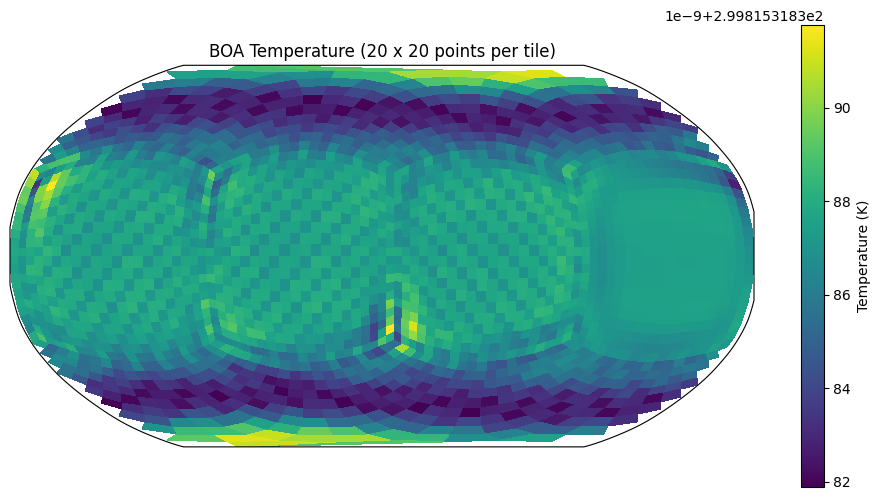

[output:0]

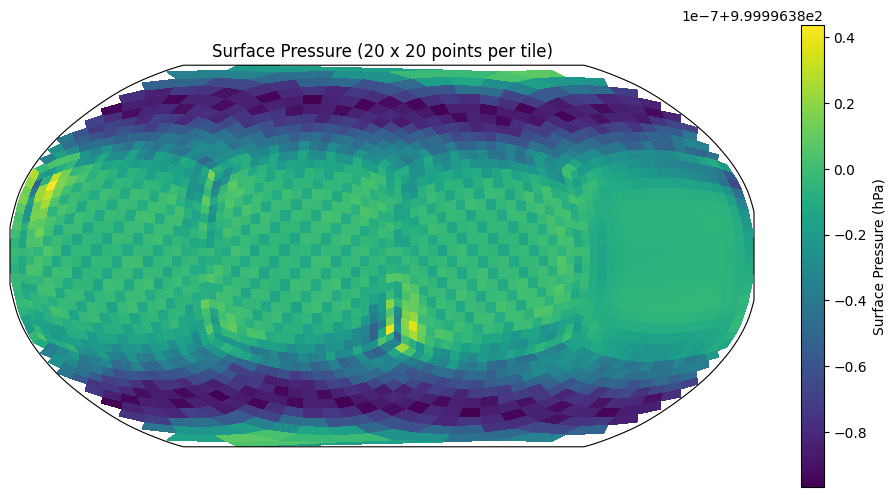

[output:0]

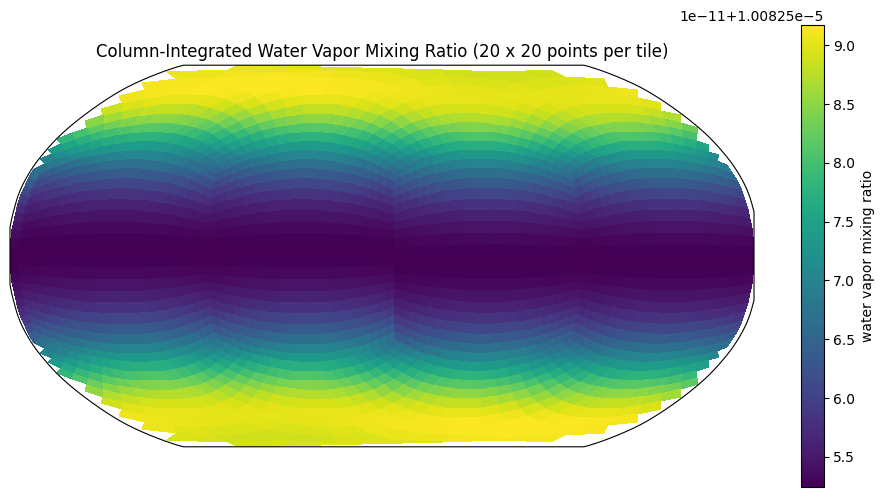

[output:0]

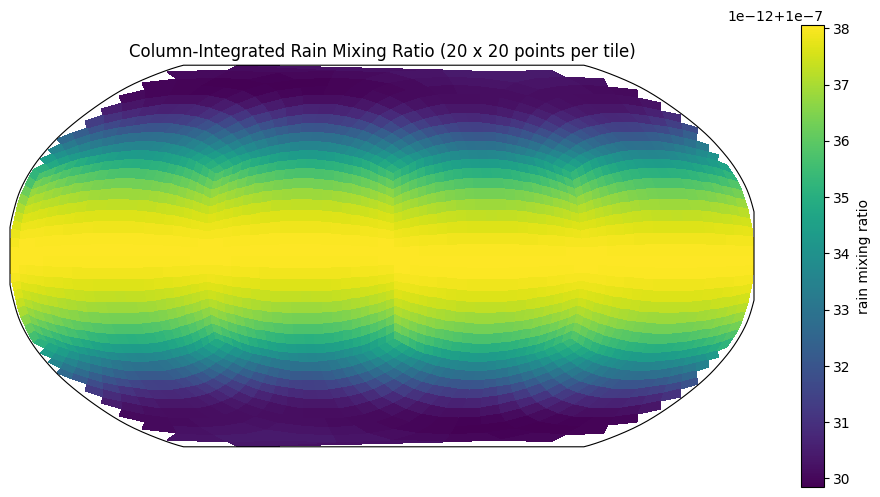

[output:0]

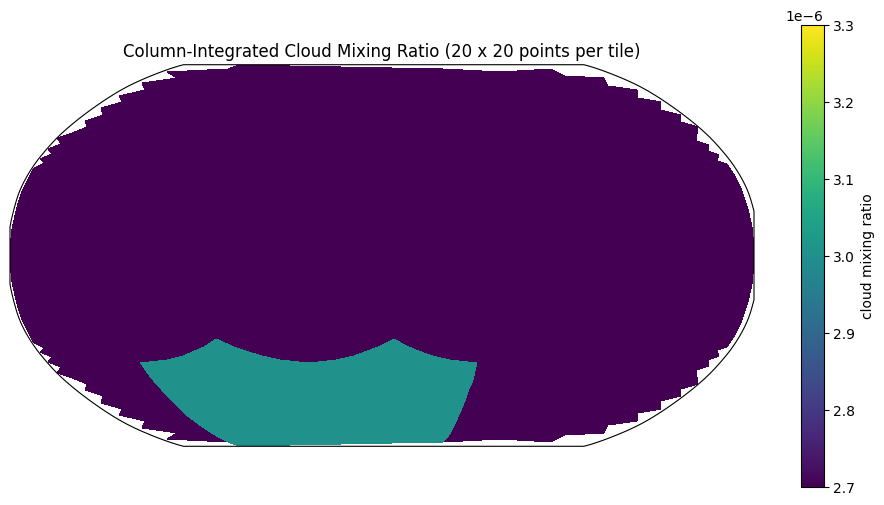

[output:0]

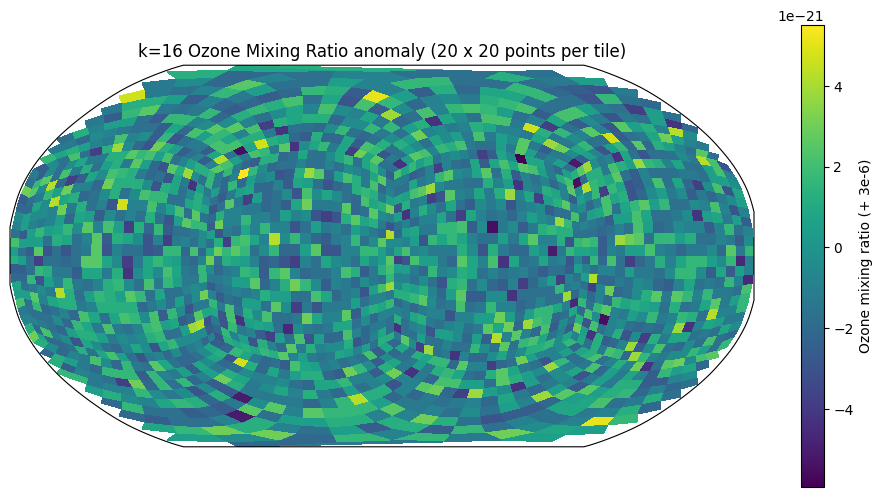

In [17]:
if mpi_rank == 0:
    rotation = -120.
    nx = temperature.shape[1]
    nz = temperature.shape[3]
    
    u_mean = 0.5 * (u_wind.data[:,:,:-1, :] + u_wind.data[:,:, 1:, :])
    column_qvap = np.sum(qvap, axis=3)/nz
    column_qcld = np.sum(qcld, axis=3)/nz
    column_qrain = np.sum(qrain, axis=3)/nz
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        temperature.data[:, :, :, -1],
        cmap="viridis",
    )
    plt.colorbar(f1, label="Temperature (K)")
    ax.set_title(f"BOA Temperature ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        surface_pressure.data[:, :, :]/100.,
        cmap="viridis",
    )
    plt.colorbar(f1, label="Surface Pressure (hPa)")
    ax.set_title(f"Surface Pressure ({nx} x {nx} points per tile)")
    
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qvap,
        cmap="viridis",
    )
    plt.colorbar(f1, label="water vapor mixing ratio")
    ax.set_title(f"Column-Integrated Water Vapor Mixing Ratio ({nx} x {nx} points per tile)")
    

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qrain,
        cmap="viridis",
    )
    plt.colorbar(f1, label="rain mixing ratio")
    ax.set_title(f"Column-Integrated Rain Mixing Ratio ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qcld,
        cmap="viridis",
    )
    plt.colorbar(f1, label="cloud mixing ratio")
    ax.set_title(f"Column-Integrated Cloud Mixing Ratio ({nx} x {nx} points per tile)")

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        qo3mr[:,:,:,16] - 3.e-6,
        cmap="viridis",
    )
    plt.colorbar(f1, label="Ozone mixing ratio (+ 3e-6)")
    ax.set_title(f"k=16 Ozone Mixing Ratio anomaly ({nx} x {nx} points per tile)")

Now let's step through

In [18]:
# %%time
# for n in range(10):
#     j+=1
#     driver.step_one(j)

In [19]:
temperature = communicator.gather(driver.state.dycore_state.pt)
surface_pressure = communicator.gather(driver.state.dycore_state.ps)
edge_pressure = communicator.gather(driver.state.dycore_state.pe)
u_wind = communicator.gather(driver.state.dycore_state.u)
ua_wind = communicator.gather(driver.state.dycore_state.ua)
v_wind = communicator.gather(driver.state.dycore_state.v)
va_wind = communicator.gather(driver.state.dycore_state.va)
w_wind = communicator.gather(driver.state.dycore_state.w)
qrain = communicator.gather(driver.state.dycore_state.qrain)
qvap = communicator.gather(driver.state.dycore_state.qvapor)
qcld = communicator.gather(driver.state.dycore_state.qcld)
phil = communicator.gather(driver.state.physics_state.phil)
land = communicator.gather(driver.state.physics_state.land)
fswd = communicator.gather(driver.state.radiation_state.fswd)
flwu = communicator.gather(driver.state.radiation_state.flwu)
flwd = communicator.gather(driver.state.radiation_state.flwd)
fswn = communicator.gather(driver.state.radiation_state.fswn)
prsl = communicator.gather(driver.state.radiation_state.prsl)
sst = communicator.gather(driver.state.sfc_state.tsfc)
ffmm = communicator.gather(driver.state.sfc_state.ffmm)
ffhh = communicator.gather(driver.state.sfc_state.ffhh)
sfcemis = communicator.gather(driver.state.sfc_state.sfcemis)
islmsk = communicator.gather(driver.state.sfc_state.islmsk)

In [20]:
if mpi_rank == 0:
    print(edge_pressure.data[:].max(), edge_pressure.data[:].min())
    print(fswd.data[:].max(), fswd.data[:].min())
    print(flwu.data[:].max(), flwu.data[:].min())
    print(edge_pressure.data[:,5,5,-16])
    print(driver.state.dycore_state.pt.field.min(), driver.state.dycore_state.pt.field.max())
    print(prsl.data[:,:,:,-1].max(), prsl.data[:,:,:,-1].min())

[stdout:0] 99999.63800437463 300.0
0.0 0.0
0.0 0.0
[86120.26593893 86120.26593893 86120.26593301 86120.26593893
 86120.26593869 86120.26593303]
199.99229325036944 299.8153183917264
0.0 0.0


[stderr:0] /tmp/ipykernel_387/3857810424.py:2: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  print(edge_pressure.data[:].max(), edge_pressure.data[:].min())
/tmp/ipykernel_387/3857810424.py:3: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  print(fswd.data[:].max(), fswd.data[:].min())
/tmp/ipykernel_387/3857810424.py:4: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  print(flwu.data[:].max(), flwu.data[:].min())
/tmp/ipykernel_387/3857810424.py:5: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  print(edge_pressure.data[:,5,5,-16])
/tmp/ipy

[stderr:0] /tmp/ipykernel_387/3868501627.py:6: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  u_mean = 0.5 * (u_wind.data[:,:,:-1, :] + u_wind.data[:,:, 1:, :])
/tmp/ipykernel_387/3868501627.py:15: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  grid_lat.data * 180./np.pi,
/tmp/ipykernel_387/3868501627.py:16: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  grid_lon.data * 180./np.pi + rotation,
/tmp/ipykernel_387/3868501627.py:17: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  temperature.data[:, :, :, -1],
/tmp/ipykernel_387/3868501627.py:

[output:0]

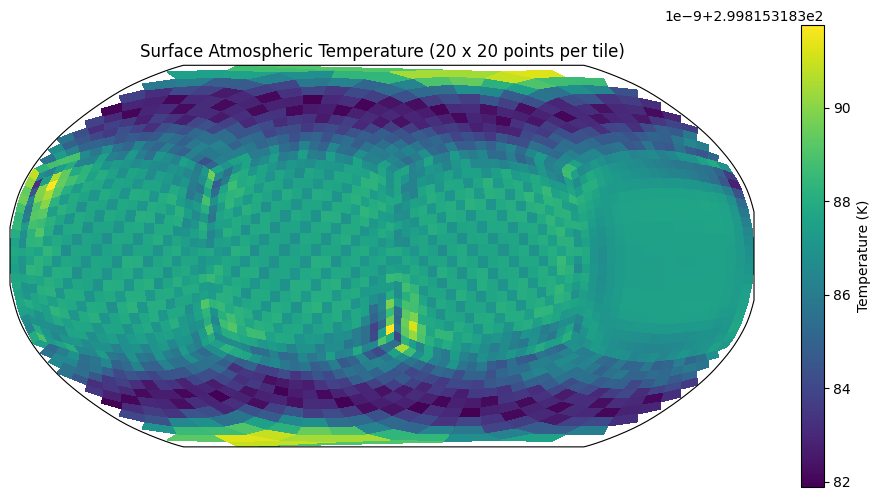

[output:0]

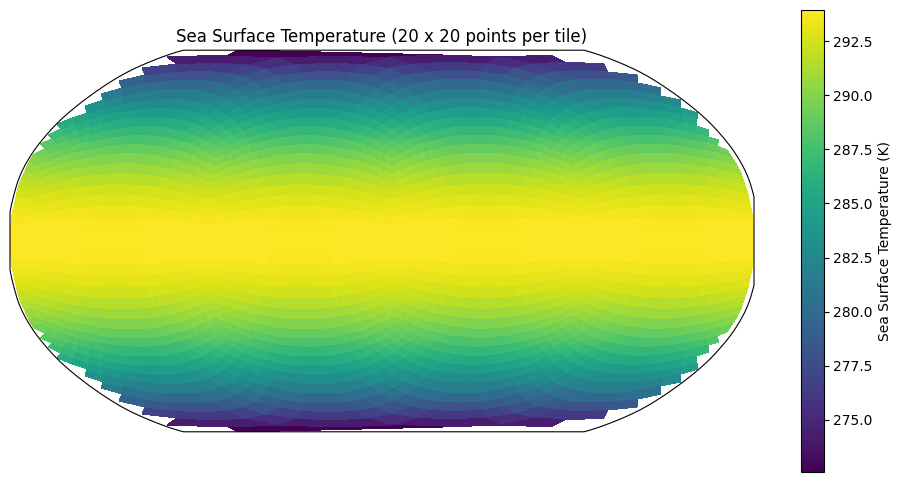

[output:0]

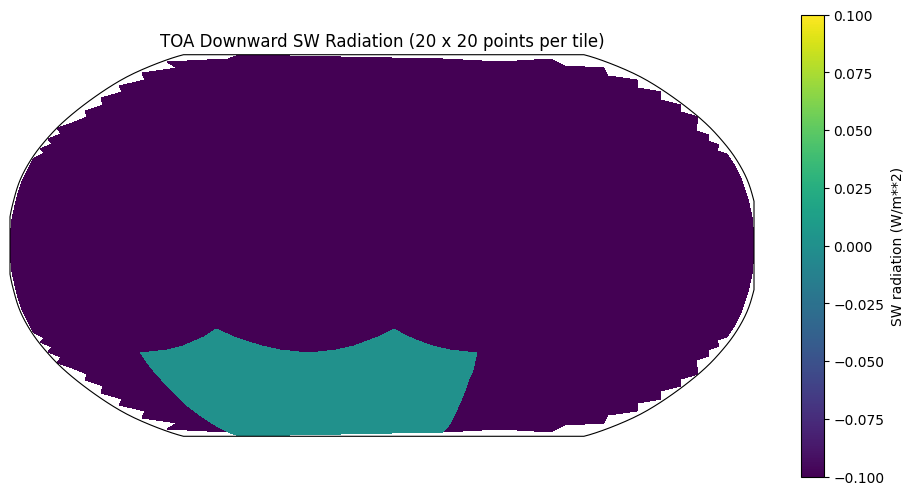

[output:0]

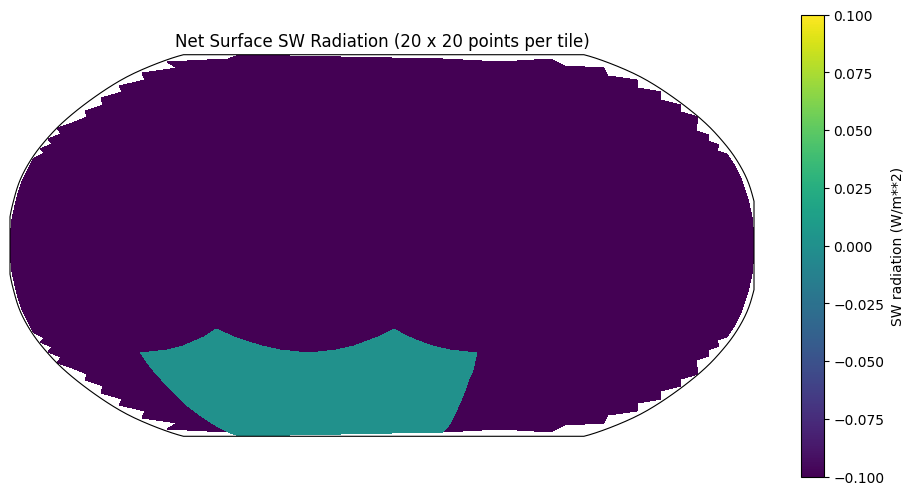

[output:0]

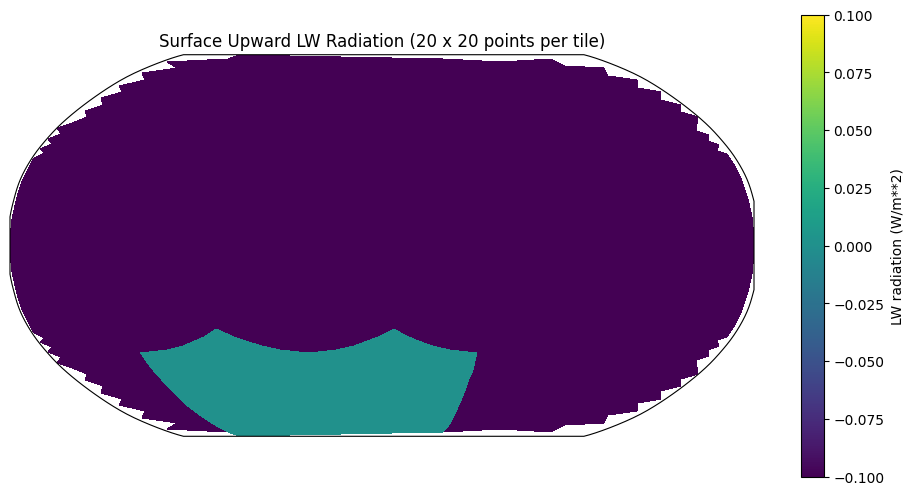

[output:0]

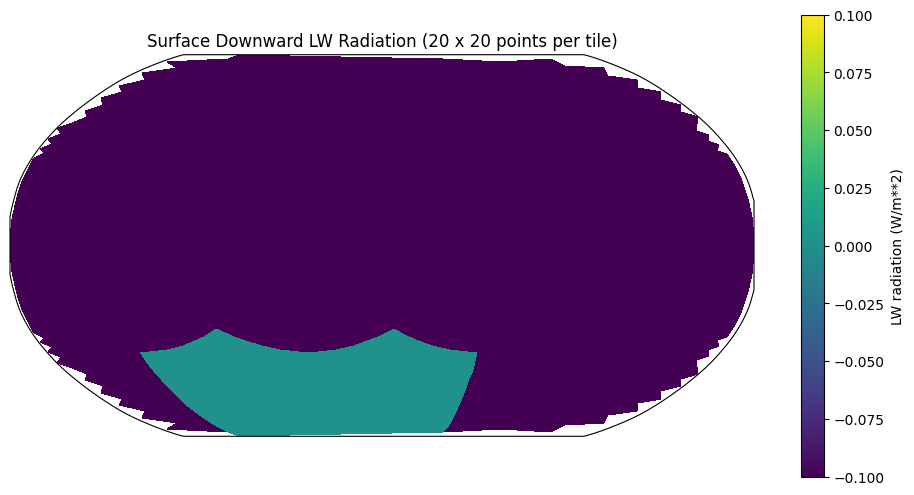

[output:0]

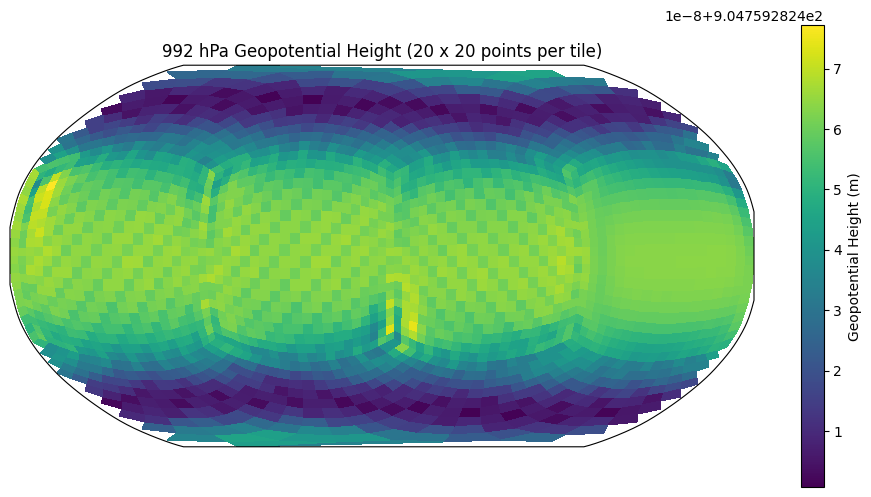

[output:0]

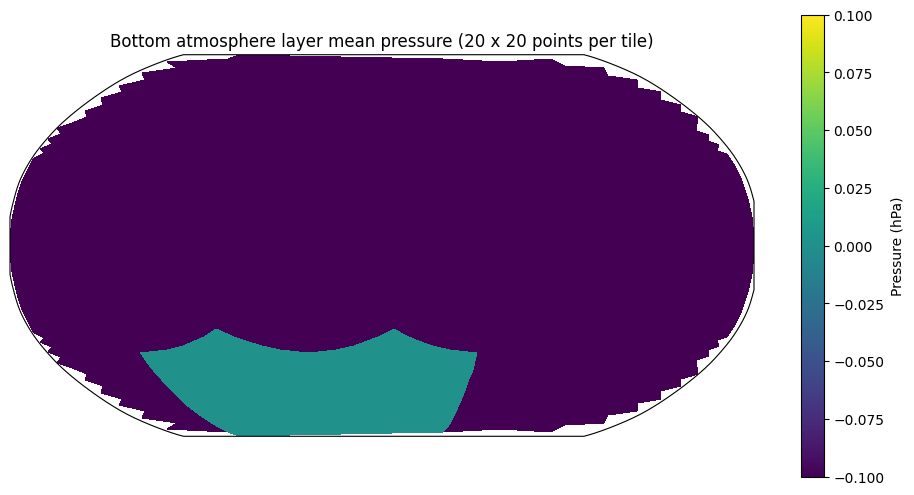

[output:0]

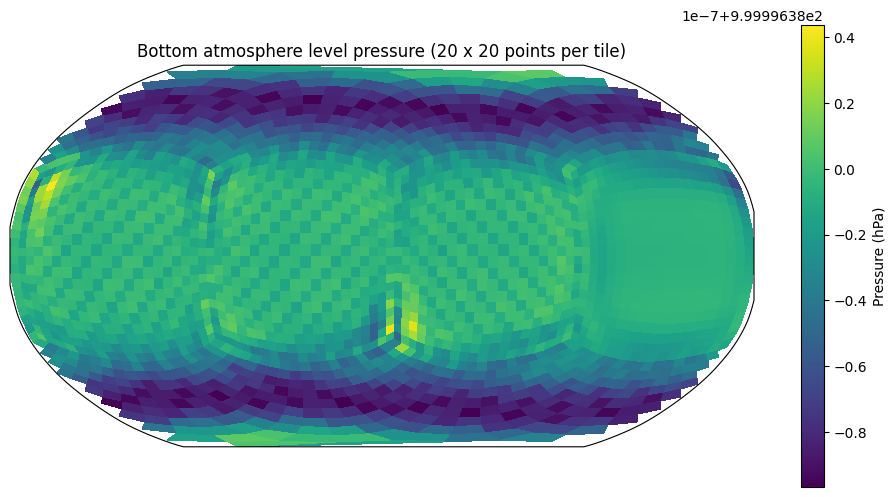

[output:0]

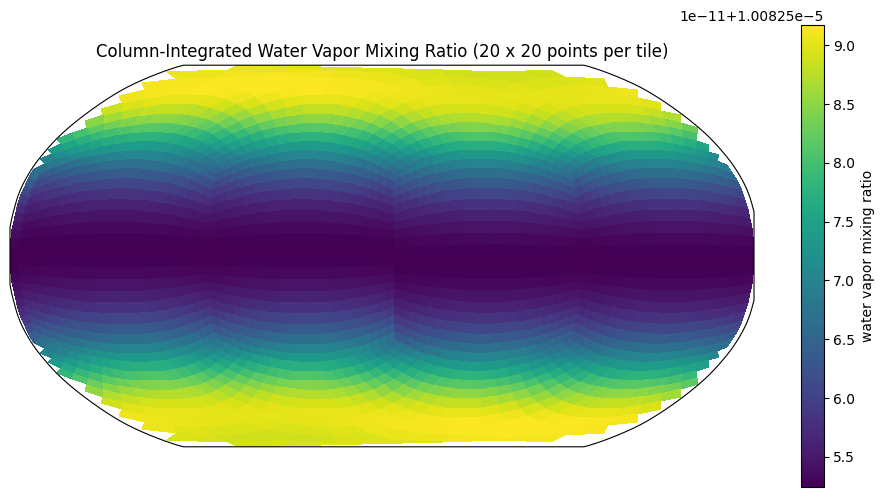

[output:0]

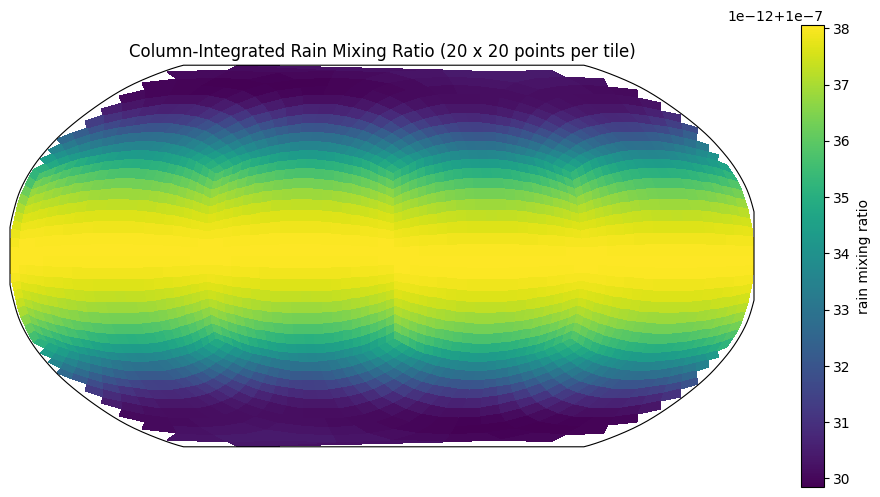

%px:   0%|                                                                                | 0/6 [00:00<?, ?tasks/s]

[output:0]

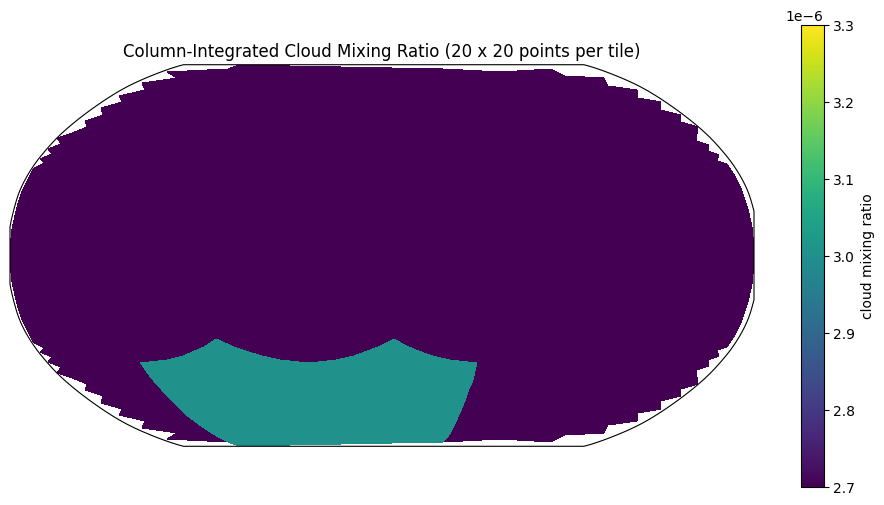

[output:0]

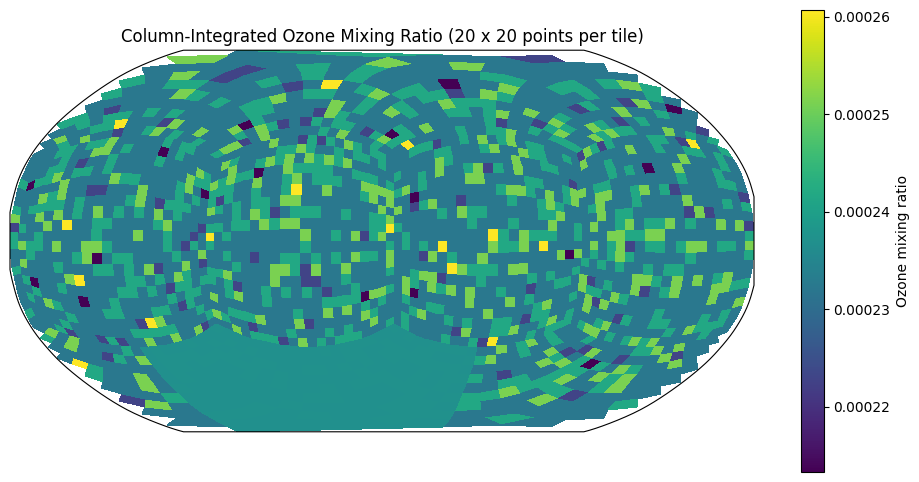

%px: 100%|███████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 129.03tasks/s]


In [21]:
if mpi_rank == 0:
    rotation = -120.
    nx = temperature.shape[1]
    nz = temperature.shape[3]
    
    u_mean = 0.5 * (u_wind.data[:,:,:-1, :] + u_wind.data[:,:, 1:, :])
    column_qvap = np.sum(qvap, axis=3)/nz
    column_qcld = np.sum(qcld, axis=3)/nz
    column_qrain = np.sum(qrain, axis=3)/nz
    column_qo3 = np.sum(qo3mr, axis=3)
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        temperature.data[:, :, :, -1],
        cmap="viridis",
    )
    plt.colorbar(f1, label="Temperature (K)")
    ax.set_title(f"Surface Atmospheric Temperature ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f5 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        sst.data[:, :, :],
        cmap="viridis",
    )
    plt.colorbar(f5, label="Sea Surface Temperature (K)")
    ax.set_title(f"Sea Surface Temperature ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f2 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        fswd.data[:, :, :, -1],
        cmap="viridis",
    )
    plt.colorbar(f2, label="SW radiation (W/m**2)")
    ax.set_title(f"TOA Downward SW Radiation ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f2 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        fswn.data[:, :, :],
        cmap="viridis",
    )
    plt.colorbar(f2, label="SW radiation (W/m**2)")
    ax.set_title(f"Net Surface SW Radiation ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f2 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        flwu.data[:, :, :, 0],
        cmap="viridis",
    )
    plt.colorbar(f2, label="LW radiation (W/m**2)")
    ax.set_title(f"Surface Upward LW Radiation ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f2 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        flwd.data[:, :, :, 0],
        cmap="viridis",
    )
    plt.colorbar(f2, label="LW radiation (W/m**2)")
    ax.set_title(f"Surface Downward LW Radiation ({nx} x {nx} points per tile)")
    
    vslice = -3
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f3 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        phil.data[:, :, :, vslice],
        cmap="viridis",
    )
    plt.colorbar(f3, label="Geopotential Height (m)")
    ax.set_title(f"{edge_pressure.field[0,3,3,vslice]/100:.0f} hPa Geopotential Height ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f3 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        prsl.data[:, :, :, 0]/100,
        cmap="viridis",
    )
    plt.colorbar(f3, label="Pressure (hPa)")
    ax.set_title(f"Bottom atmosphere layer mean pressure ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f3 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        edge_pressure.data[:, :, :, -1]/100,
        cmap="viridis",
    )
    plt.colorbar(f3, label="Pressure (hPa)")
    ax.set_title(f"Bottom atmosphere level pressure ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qvap,
        cmap="viridis",
    )
    plt.colorbar(f1, label="water vapor mixing ratio")
    ax.set_title(f"Column-Integrated Water Vapor Mixing Ratio ({nx} x {nx} points per tile)")
    

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qrain,
        cmap="viridis",
    )
    plt.colorbar(f1, label="rain mixing ratio")
    ax.set_title(f"Column-Integrated Rain Mixing Ratio ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qcld,
        cmap="viridis",
    )
    plt.colorbar(f1, label="cloud mixing ratio")
    ax.set_title(f"Column-Integrated Cloud Mixing Ratio ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qo3,
        cmap="viridis",
    )
    plt.colorbar(f1, label="Ozone mixing ratio")
    ax.set_title(f"Column-Integrated Ozone Mixing Ratio ({nx} x {nx} points per tile)")

[output:1]

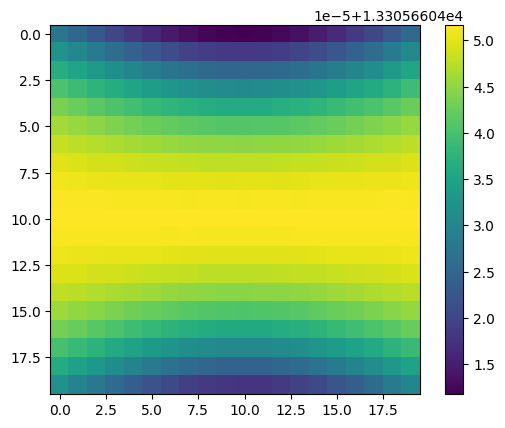

In [22]:
if mpi_rank == 1:
    plt.imshow(driver.state.physics_state.phil.field[:,:,-16].transpose())
    plt.colorbar()

[output:1]

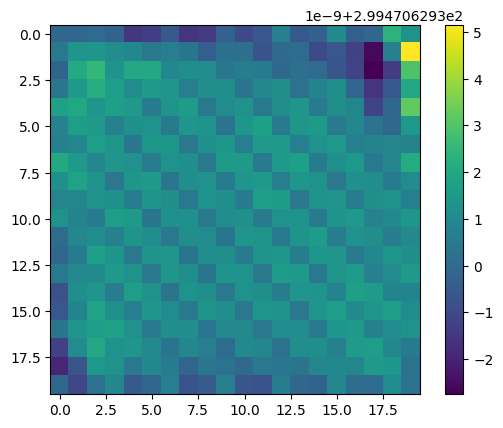

In [23]:
if mpi_rank == 1:
    plt.imshow(driver.state.dycore_state.pt.field[:,:,-2].transpose())
    plt.colorbar()

[output:1]

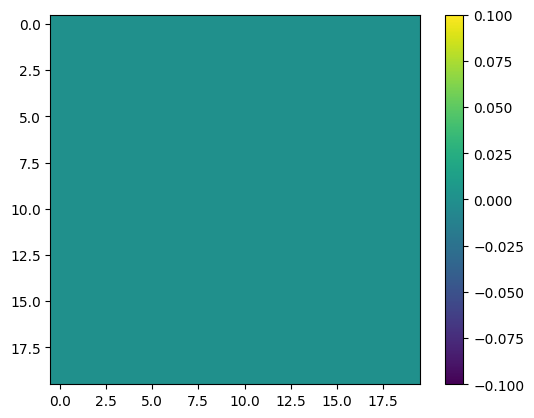

In [24]:
if mpi_rank == 1:
    plt.imshow(driver.state.physics_state.fswd.field[:,:,0].transpose())
    plt.colorbar()

In [25]:
px=6
py=8

[output:1]

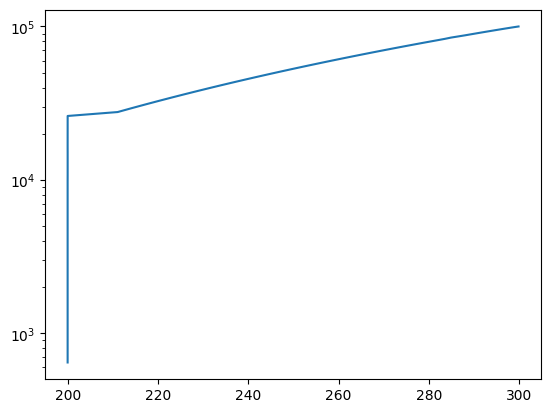

In [26]:
if mpi_rank == 1:
    plt.semilogy(driver.state.dycore_state.pt.field[px, py, :], driver.state.dycore_state.pe.field[px, py, 1:])

[stdout:1] Heating is 0.0 + 0.0 = 0.0


[output:1]

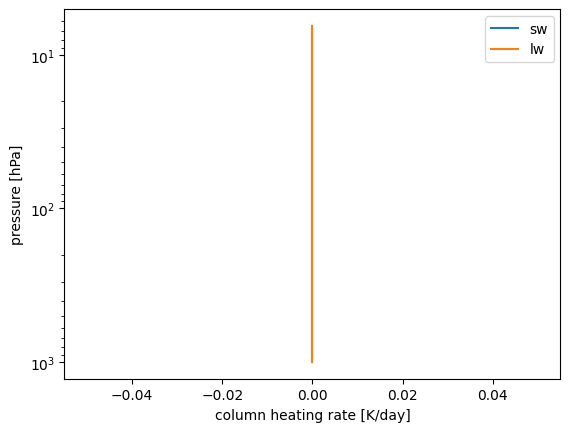

In [27]:
if mpi_rank == 1:
    plt.gca().invert_yaxis()
    plt.semilogy(driver.state.physics_state.hrtsw.field[px, py, :]*86400, driver.state.dycore_state.pe.field[px, py, 1:]/100, label="sw")
    plt.semilogy(driver.state.physics_state.hrtlw.field[px, py, :]*86400, driver.state.dycore_state.pe.field[px, py, 1:]/100, label="lw")
    plt.xlabel("column heating rate [K/day]")
    plt.ylabel("pressure [hPa]")
    plt.legend()

    hsw = driver.state.physics_state.hrtsw.field[px, py, :].sum()*86400
    hlw = driver.state.physics_state.hrtlw.field[px, py, :].sum()*86400
    print(f"Heating is {hsw} + {hlw} = {hsw + hlw}")

[stdout:4] Heating is 0.0 + 0.0 = 0.0
0
[  6.46715763  10.45221694  14.69187518  18.97828343  23.25384171
  27.54394998  31.91292824  36.48330644  41.35673454  46.68280246
  52.47938021  58.76268778  65.54713516  72.84518235  80.66734926
  89.02184591  97.91478219 107.34985806 117.32839963 127.84979353
 138.91064042 150.50541089 162.6267569  175.26441763 188.40676357
 202.03996511 216.14850263 230.71477643 245.72045677 261.14498383
 276.96701741 293.16384801 309.71207574 326.58740074 343.76482315
 361.21914314 378.9245609  396.85507667 414.98449068 433.2871032
 451.73721448 470.30932479 488.97853437 507.71974348 526.50945236
 545.32376125 564.14022038 582.93672996 601.69238021 620.38672131
 639.00026344 657.51497673 675.91276133 694.17753732 712.27458485
 730.16566406 747.81185507 765.17415796 782.21335281 798.89038967
 815.16622904 831.00224543 846.36028986 861.20265939 875.49230561
 889.19359424 902.27178563 914.69309994 926.42539732 937.43784791
 947.70140185 957.18878526 965.874418

[output:4]

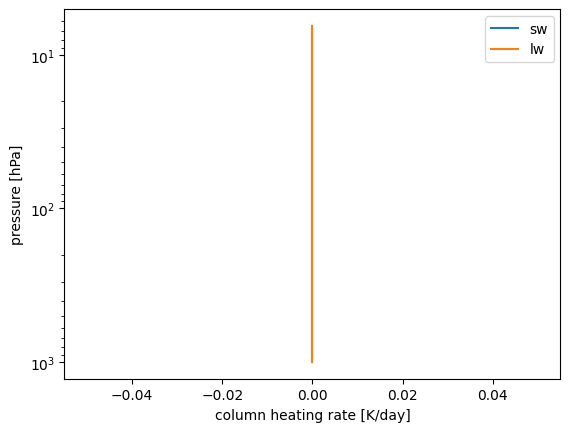

In [28]:
if mpi_rank == 4:
    plt.gca().invert_yaxis()
    plt.semilogy(driver.state.physics_state.hrtsw.field[px, py, :]*86400, driver.state.dycore_state.pe.field[px, py, 1:]/100, label="sw")
    plt.semilogy(driver.state.physics_state.hrtlw.field[px, py, :]*86400, driver.state.dycore_state.pe.field[px, py, 1:]/100, label="lw")
    plt.xlabel("column heating rate [K/day]")
    plt.ylabel("pressure [hPa]")
    plt.legend()
    
    hsw = driver.state.physics_state.hrtsw.field[px, py, :].sum()*86400
    hlw = driver.state.physics_state.hrtlw.field[px, py, :].sum()*86400
    print(f"Heating is {hsw} + {hlw} = {hsw + hlw}")
    print(driver.state.physics_state.hrtlw.field[px, py, :].argmax())
    print(driver.state.dycore_state.pe.field[px, py, 1:]/100)
    print(driver.state.physics_state.hrtlw.field[px, py, :] * 86400)

[stderr:4] /usr/local/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  func(*args, **kwargs)


[output:4]

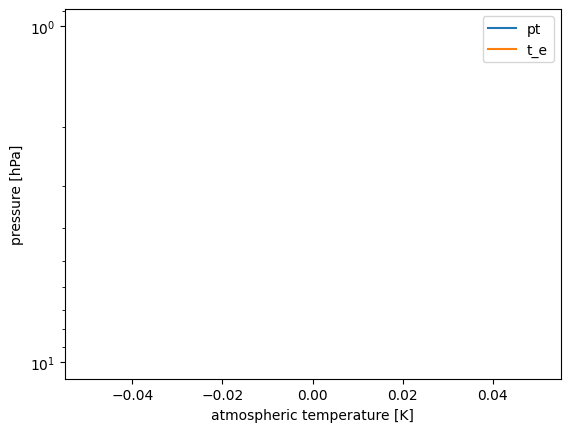

In [29]:
if mpi_rank == 4:
    plt.gca().invert_yaxis()
    plt.semilogy(driver.state.radiation_state.tlyr.field[px, py, ::-1], driver.state.radiation_state.prsl.field[px, py, ::-1]/100, label="pt")
    plt.semilogy(driver.state.radiation_state.tlvl.field[px, py, ::-1], driver.state.radiation_state.prsi.field[px, py, ::-1]/100, label="t_e")
    plt.xlabel("atmospheric temperature [K]")
    plt.ylabel("pressure [hPa]")
    plt.legend()

In [30]:
if mpi_rank == 0:
        lats = grid_lat.data * 180./np.pi
        lons = grid_lon.data * 180./np.pi - 120.
        np.save("lats", lats)
        np.save("lons", lons)
        print(lats.shape)

[stdout:0] (6, 21, 21)


[stderr:0] /tmp/ipykernel_387/2991721731.py:2: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  lats = grid_lat.data * 180./np.pi
/tmp/ipykernel_387/2991721731.py:3: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  lons = grid_lon.data * 180./np.pi - 120.


In [31]:
htrs = communicator.gather(driver.state.physics_state.hrtsw)
htrl = communicator.gather(driver.state.physics_state.hrtlw)

In [32]:
if mpi_rank == 0:
    print(type(np.sum(htrl, axis=3)*86400))

[stdout:0] <class 'numpy.ndarray'>


[stderr:0] /tmp/ipykernel_387/250752684.py:13: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  grid_lat.data * 180./np.pi,
/tmp/ipykernel_387/250752684.py:14: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  grid_lon.data * 180./np.pi + rotation,
/tmp/ipykernel_387/250752684.py:24: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  grid_lat.data * 180./np.pi,
/tmp/ipykernel_387/250752684.py:25: UserWarning: Quantity.data accessor is now deprecated. Use a slicing operation directly onthe quantity, e.g. `my_quantity[:]` instead of `my_quantity.data[:]`
  grid_lon.data * 180./np.pi + rotation,
/tmp/ipykernel_387/250752684.py:35: UserWarning: Quantity.data acce

[output:0]

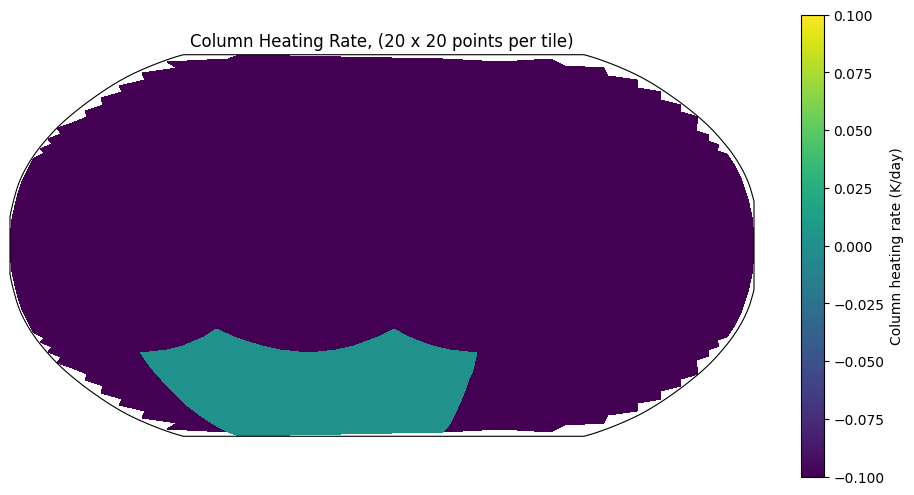

[output:0]

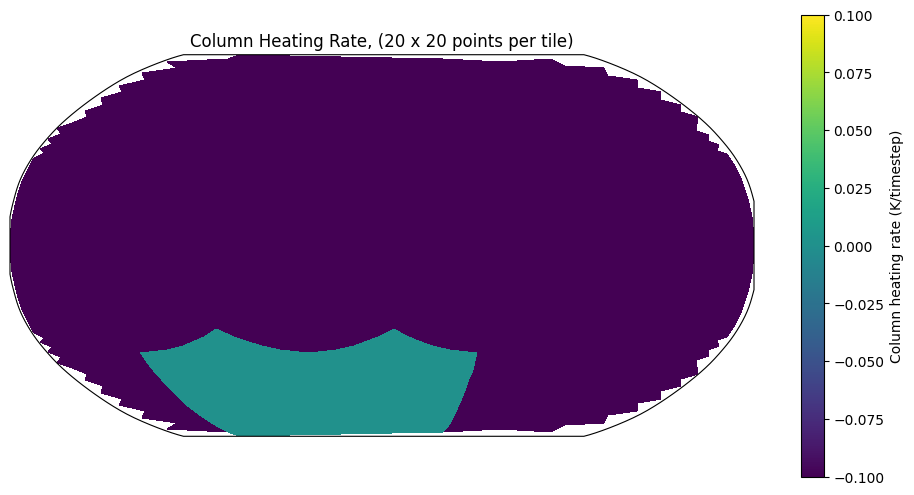

[output:0]

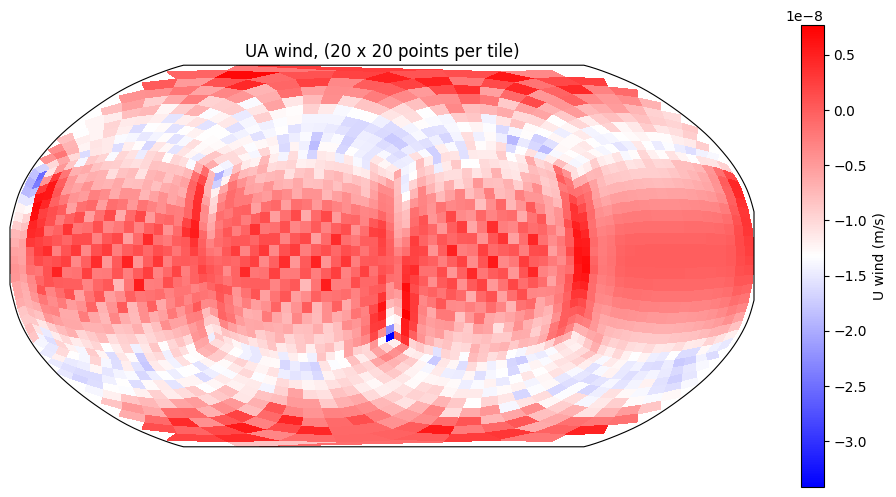

[output:0]

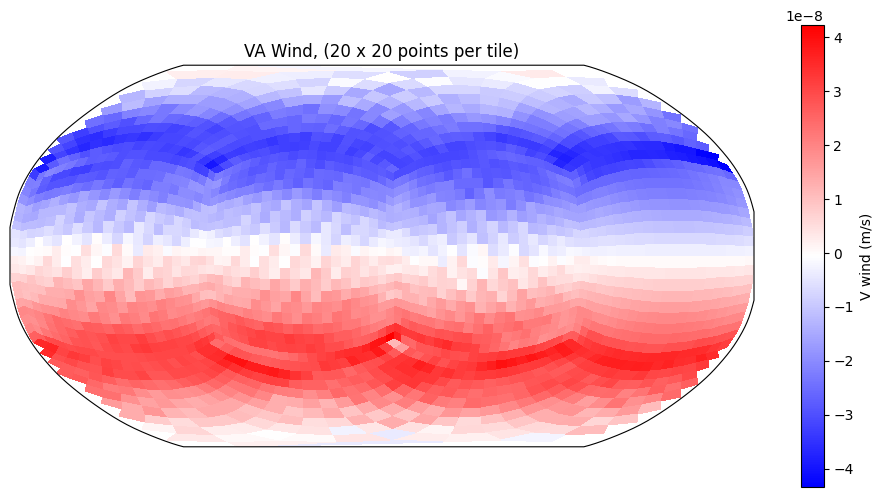

[output:0]

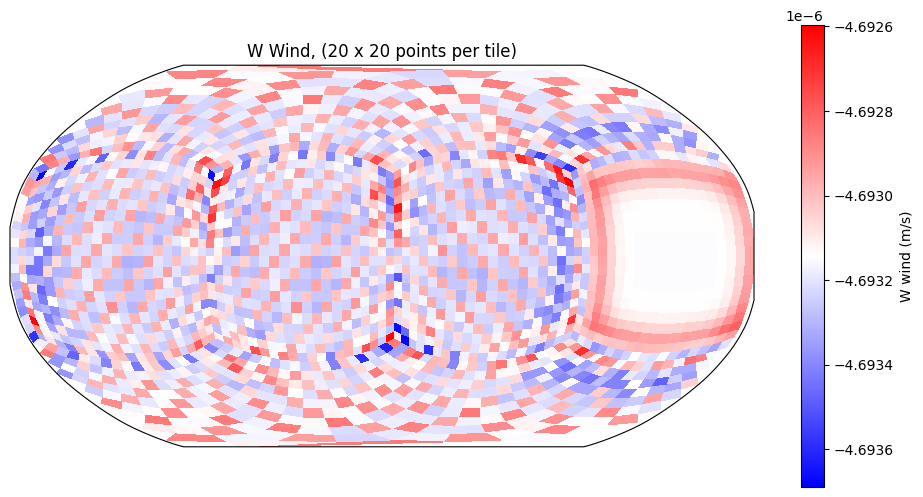

In [33]:
if mpi_rank == 0:
    rotation = -120.
    nx = temperature.shape[1]
    nz = temperature.shape[3]
    
    column_htrs = np.sum(htrs, axis=3)*86400
    column_htrl = np.sum(htrl, axis=3)*86400
    column_heat = column_htrs + column_htrl
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_heat,
        cmap="viridis",
    )
    plt.colorbar(f1, label="Column heating rate (K/day)")
    ax.set_title(f"Column Heating Rate, ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f2 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_heat * driver.config.dt_atmos / 86400,
        cmap="viridis",
    )
    plt.colorbar(f2, label="Column heating rate (K/timestep)")
    ax.set_title(f"Column Heating Rate, ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f3 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        ua_wind.field[:,:,:,16],
        cmap="bwr",
    )
    plt.colorbar(f3, label="U wind (m/s)")
    ax.set_title(f"UA wind, ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f4 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        va_wind.field[:,:,:,16],
        cmap="bwr",
    )
    plt.colorbar(f4, label="V wind (m/s)")
    ax.set_title(f"VA Wind, ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f5 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        w_wind.field[:,:,:,16],
        cmap="bwr",
    )
    plt.colorbar(f5, label="W wind (m/s)")
    ax.set_title(f"W Wind, ({nx} x {nx} points per tile)")

[output:0]

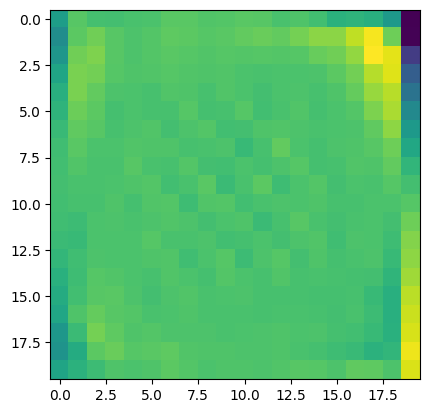

In [34]:
if mpi_rank == 0:
    plt.imshow(ua_wind.field[1, :, :, -1].transpose())

[output:1]

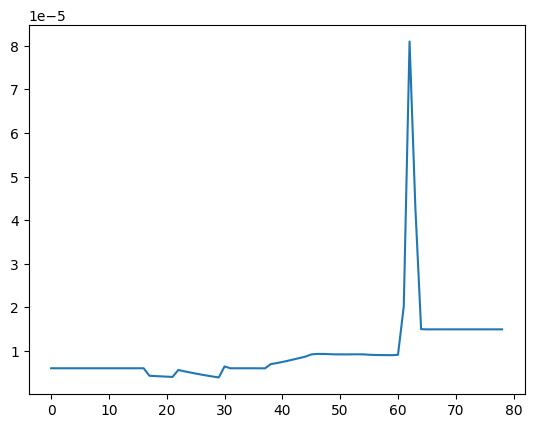

In [35]:
if mpi_rank == 1:
    plt.plot(driver.state.physics_state.qvapor.field[px, py, :])

In [36]:
# %autopx

In [37]:
# cluster.shutdown(hub=True)